In [4]:
!pip install openmeteo-requests
!pip install requests-cache retry-requests

  Using cached openmeteo_requests-1.7.3-py3-none-any.whl.metadata (11 kB)
  Using cached niquests-3.15.2-py3-none-any.whl.metadata (16 kB)
  Using cached openmeteo_sdk-1.21.2-py3-none-any.whl.metadata (935 bytes)
  Using cached urllib3_future-2.14.901-py3-none-any.whl.metadata (16 kB)
  Using cached wassima-2.0.1-py3-none-any.whl.metadata (3.7 kB)
  Using cached flatbuffers-25.2.10-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached jh2-5.0.9-cp37-abi3-win_amd64.whl.metadata (4.0 kB)
  Using cached qh3-1.5.4-cp37-abi3-win_amd64.whl.metadata (4.8 kB)
Using cached openmeteo_requests-1.7.3-py3-none-any.whl (7.0 kB)
Using cached niquests-3.15.2-py3-none-any.whl (167 kB)
Using cached openmeteo_sdk-1.21.2-py3-none-any.whl (17 kB)
Using cached flatbuffers-25.2.10-py2.py3-none-any.whl (30 kB)
Using cached urllib3_future-2.14.901-py3-none-any.whl (675 kB)
Using cached wassima-2.0.1-py3-none-any.whl (145 kB)
Using cached h11-0.16.

In [20]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import numpy as np

In [22]:
# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 35.6768601,
	"longitude": 139.7638947,
	"start_date": "2022-01-01",
	"end_date": "2025-09-26",
	"hourly": ["temperature_2m", "relative_humidity_2m", "precipitation", "rain", "snowfall", "pressure_msl", "cloud_cover", "cloud_cover_low", "cloud_cover_high", "cloud_cover_mid", "wind_speed_10m", "wind_direction_10m", "wind_speed_100m", "wind_direction_100m", "weather_code"],
	# "bounding_box": "-90,-180,90,180",
}
responses = openmeteo.weather_api(url, params=params)

# Process bounding box locations
for response in responses:
	print(f"\nCoordinates: {response.Latitude()}°N {response.Longitude()}°E")
	print(f"Elevation: {response.Elevation()} m asl")
	print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")
	
	# Process hourly data. The order of variables needs to be the same as requested.
	hourly = response.Hourly()
	hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
	hourly_relative_humidity_2m = hourly.Variables(1).ValuesAsNumpy()
	hourly_precipitation = hourly.Variables(2).ValuesAsNumpy()
	hourly_rain = hourly.Variables(3).ValuesAsNumpy()
	hourly_snowfall = hourly.Variables(4).ValuesAsNumpy()
	hourly_pressure_msl = hourly.Variables(5).ValuesAsNumpy()
	hourly_cloud_cover = hourly.Variables(6).ValuesAsNumpy()
	hourly_cloud_cover_low = hourly.Variables(7).ValuesAsNumpy()
	hourly_cloud_cover_high = hourly.Variables(8).ValuesAsNumpy()
	hourly_cloud_cover_mid = hourly.Variables(9).ValuesAsNumpy()
	hourly_wind_speed_10m = hourly.Variables(10).ValuesAsNumpy()
	hourly_wind_direction_10m = hourly.Variables(11).ValuesAsNumpy()
	hourly_wind_speed_100m = hourly.Variables(12).ValuesAsNumpy()
	hourly_wind_direction_100m = hourly.Variables(13).ValuesAsNumpy()
	hourly_weather_code = hourly.Variables(14).ValuesAsNumpy()
	
	hourly_data = {"date": pd.date_range(
		start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
		end = pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = hourly.Interval()),
		inclusive = "left"
	)}
	
	hourly_data["temperature_2m"] = hourly_temperature_2m
	hourly_data["relative_humidity_2m"] = hourly_relative_humidity_2m
	hourly_data["precipitation"] = hourly_precipitation
	hourly_data["rain"] = hourly_rain
	hourly_data["snowfall"] = hourly_snowfall
	hourly_data["pressure_msl"] = hourly_pressure_msl
	hourly_data["cloud_cover"] = hourly_cloud_cover
	hourly_data["cloud_cover_low"] = hourly_cloud_cover_low
	hourly_data["cloud_cover_high"] = hourly_cloud_cover_high
	hourly_data["cloud_cover_mid"] = hourly_cloud_cover_mid
	hourly_data["wind_speed_10m"] = hourly_wind_speed_10m
	hourly_data["wind_direction_10m"] = hourly_wind_direction_10m
	hourly_data["wind_speed_100m"] = hourly_wind_speed_100m
	hourly_data["wind_direction_100m"] = hourly_wind_direction_100m
	hourly_data["weather_code"] = hourly_weather_code
	
	hourly_dataframe = pd.DataFrame(data = hourly_data)
	hourly_dataframe


Coordinates: 35.6766242980957°N 139.80694580078125°E
Elevation: 27.0 m asl
Timezone difference to GMT+0: 0s


In [26]:
hourly_dataframe.to_csv("data/weather.csv", index = False)

In [23]:
hourly_dataframe['temperature_2m']

0         2.731000
1         4.381000
2         5.231000
3         5.581000
4         5.431000
           ...    
32755    22.130999
32756    21.830999
32757    21.730999
32758    21.880999
32759    22.330999
Name: temperature_2m, Length: 32760, dtype: float32

In [25]:
hourly_dataframe.rename(columns={'date': 'date_time'}, inplace=True)

In [15]:
df = hourly_dataframe.copy()

In [17]:
df['date']

0       2022-01-18 00:00:00+00:00
1       2022-01-18 01:00:00+00:00
2       2022-01-18 02:00:00+00:00
3       2022-01-18 03:00:00+00:00
4       2022-01-18 04:00:00+00:00
                   ...           
32491   2025-10-02 19:00:00+00:00
32492   2025-10-02 20:00:00+00:00
32493   2025-10-02 21:00:00+00:00
32494   2025-10-02 22:00:00+00:00
32495   2025-10-02 23:00:00+00:00
Name: date, Length: 32496, dtype: datetime64[ns, UTC]

In [18]:
df.set_index('date', inplace=True)


--- Memulai Tahap 1: Analisis Data Eksplorasi (EDA) ---


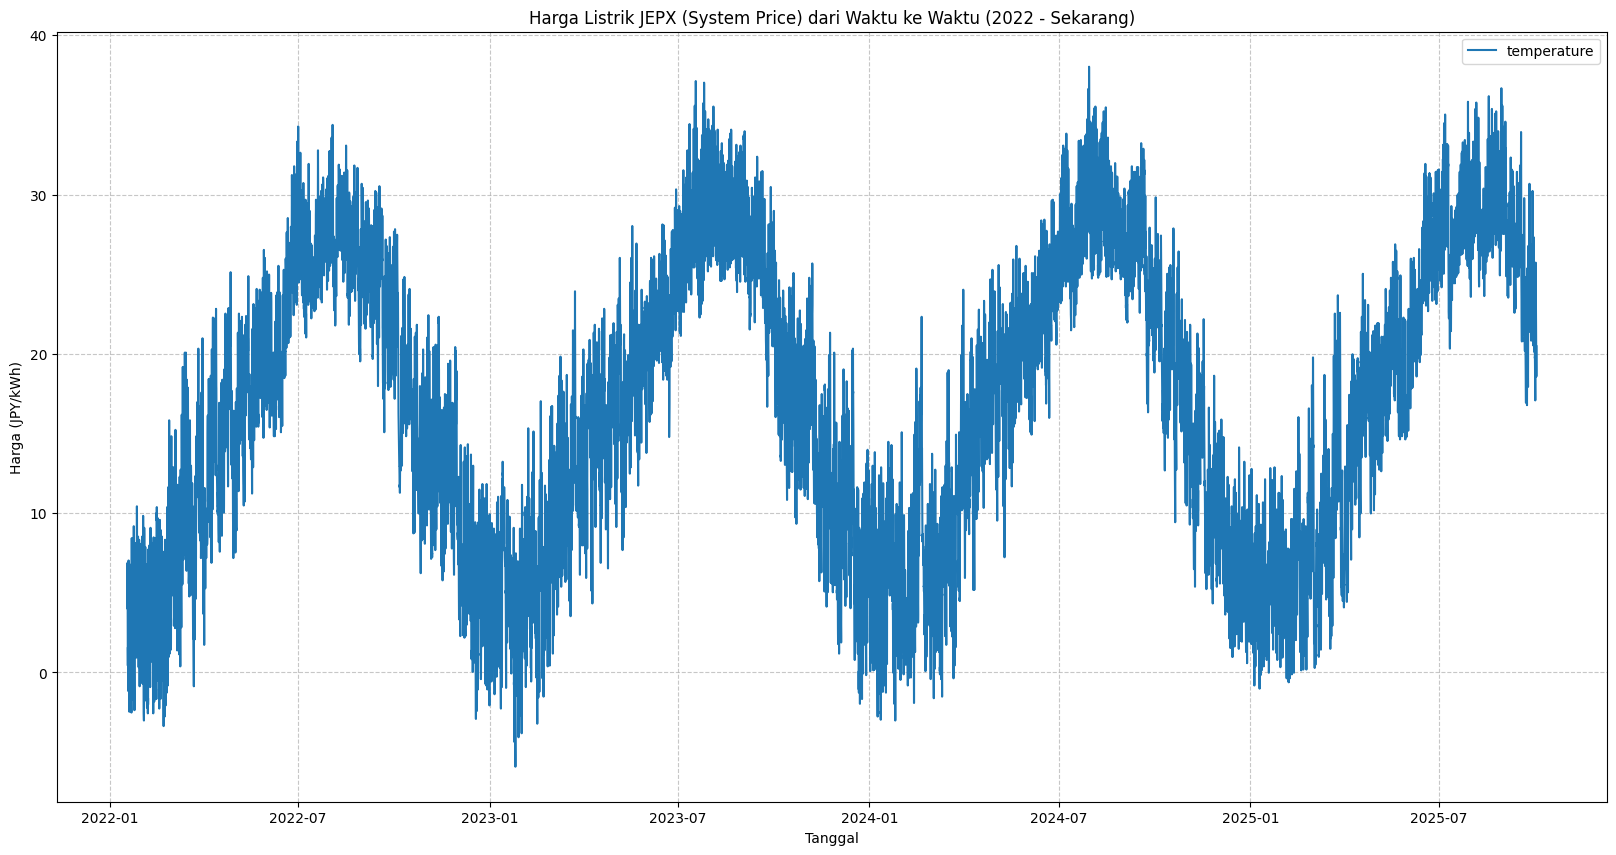


--- Plot Dekomposisi Musiman (Tahun 2022) ---


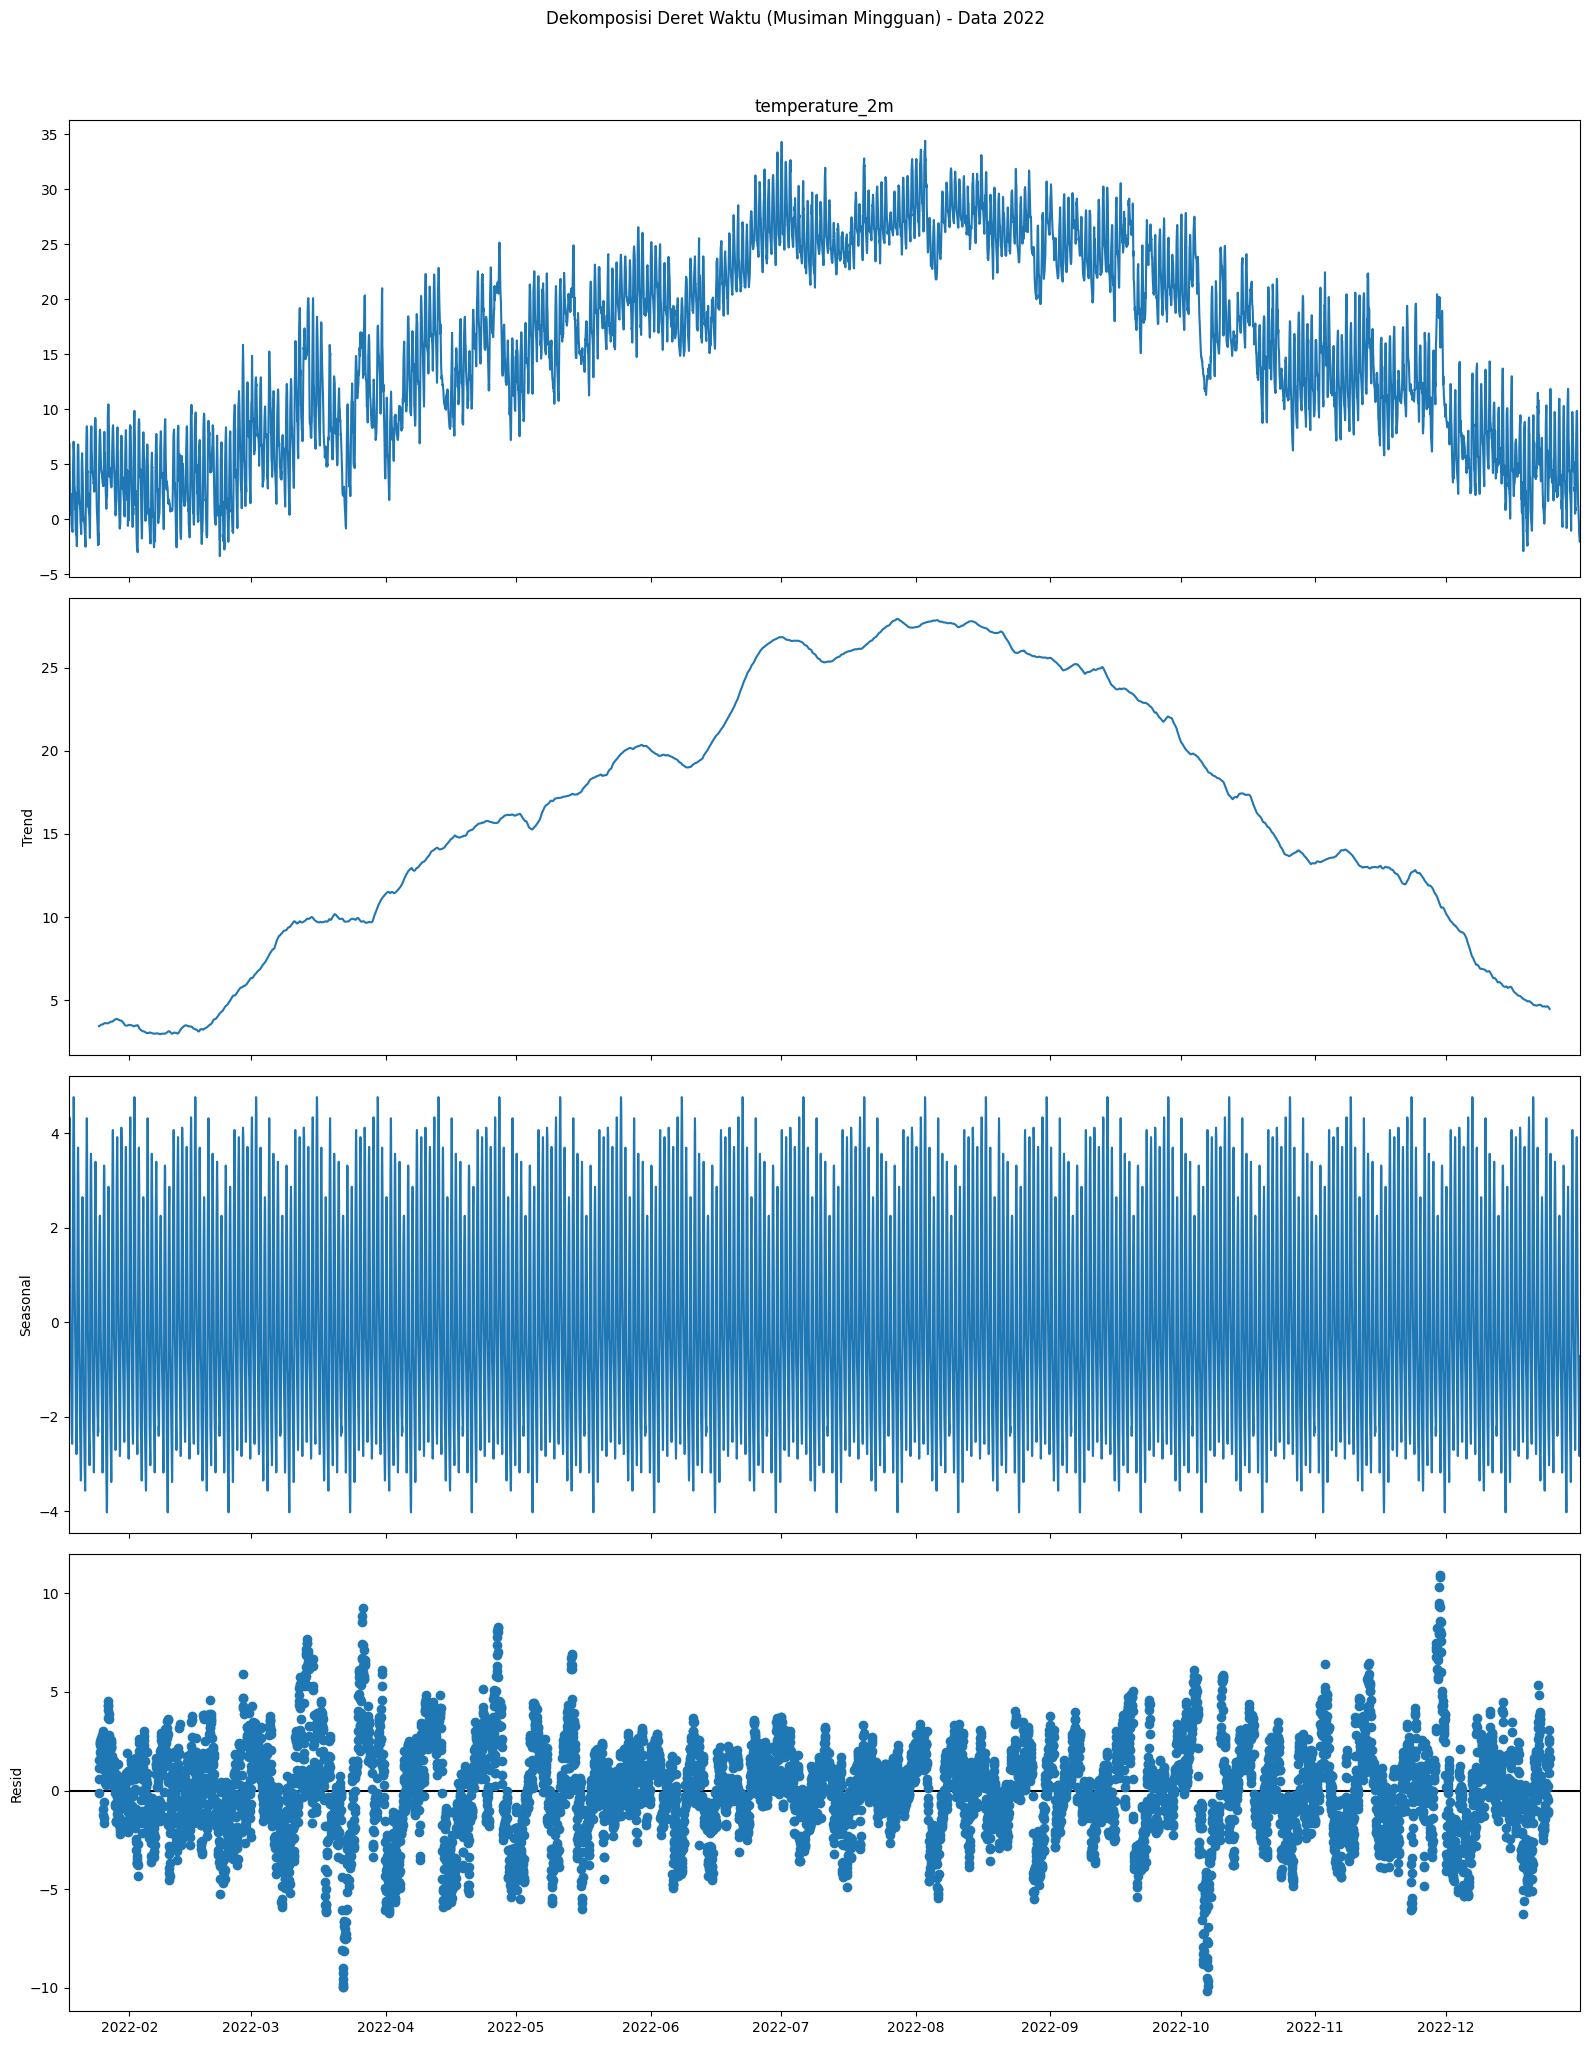


--- Box Plot Musiman ---


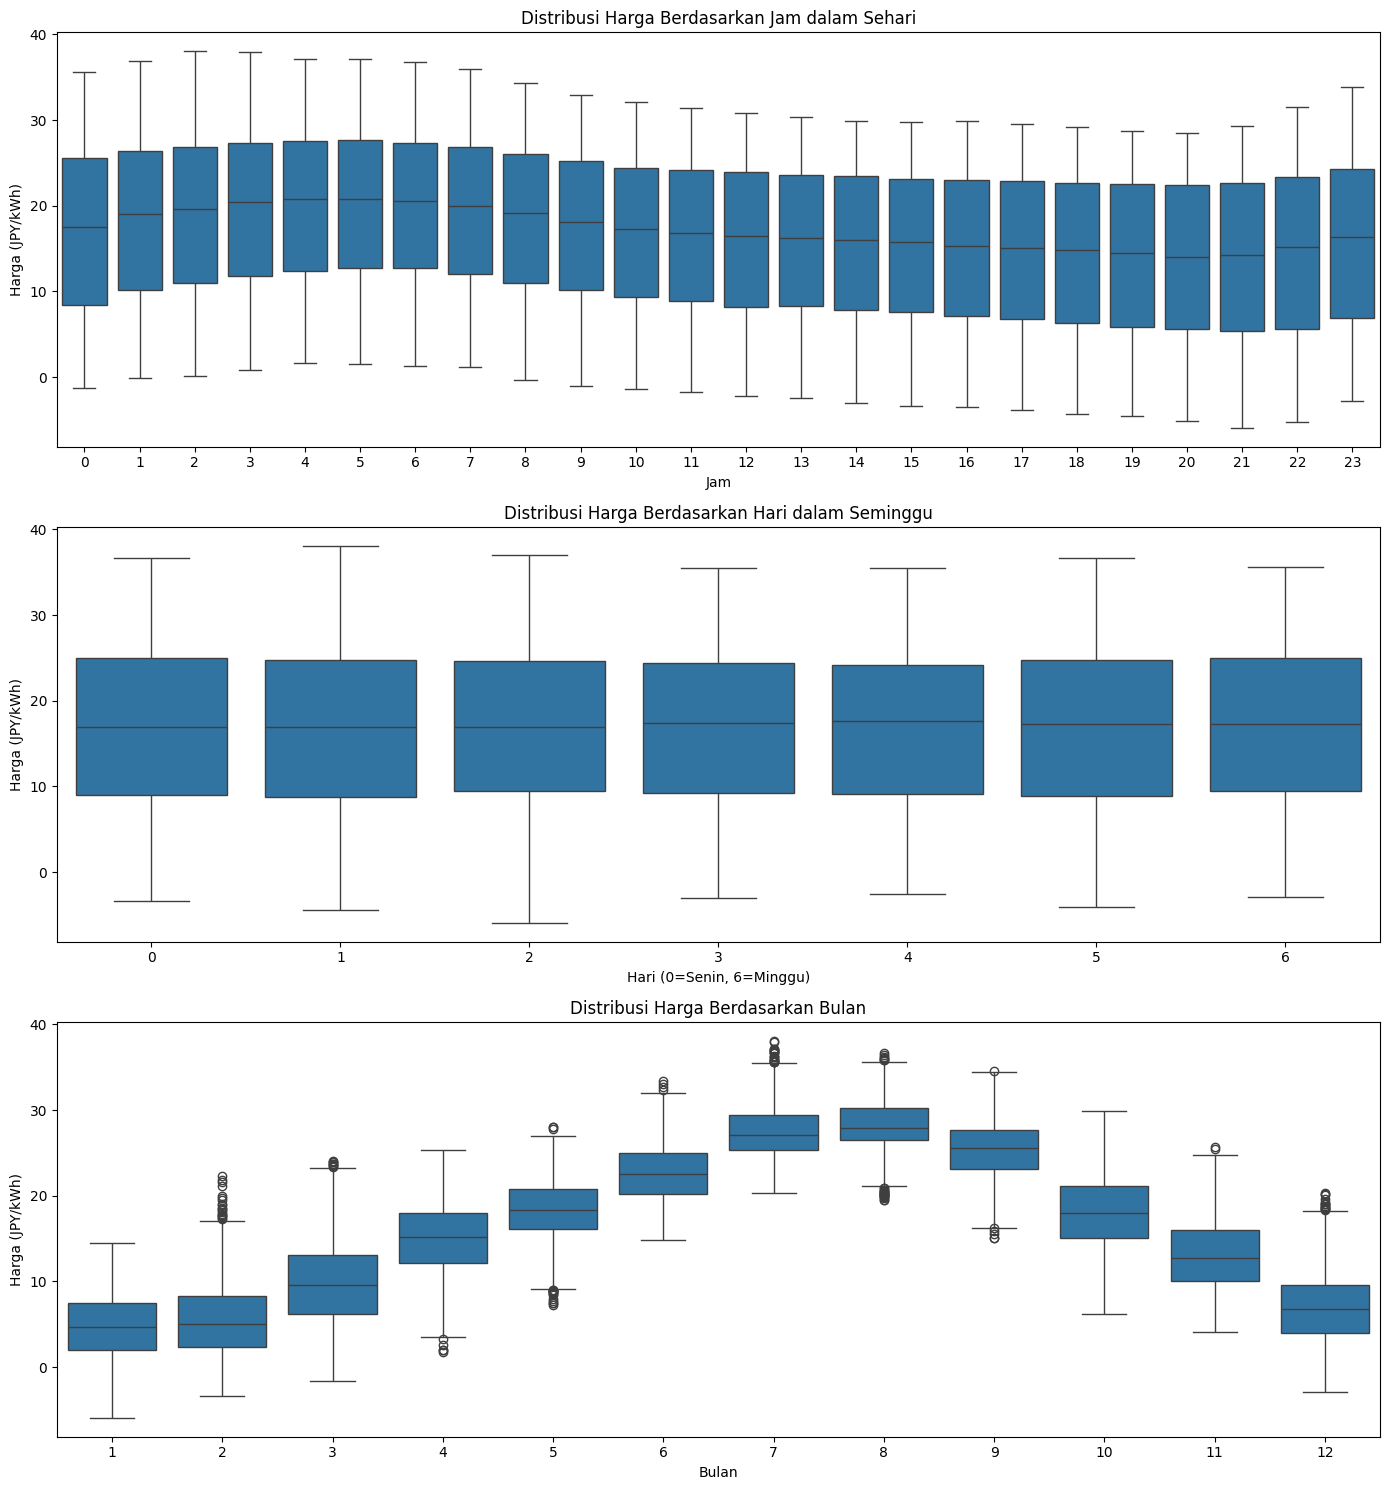

In [19]:
# TAHAP 1: ANALISIS DATA EKSPLORASI (EDA)

print("\n--- Memulai Tahap 1: Analisis Data Eksplorasi (EDA) ---")

# 1.1. Visualisasi Data Awal

TARGET = 'temperature_2m'

# 1.1. Visualisasi Data Awal

# Plot Deret Waktu Keseluruhan
plt.figure(figsize=(20, 10))
plt.plot(df.index, df[TARGET], label='temperature')
plt.title('Harga Listrik JEPX (System Price) dari Waktu ke Waktu (2022 - Sekarang)')
plt.xlabel('Tanggal')
plt.ylabel('Harga (JPY/kWh)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# ---
# Catatan: Untuk Dekomposisi Musiman, period=48*7 (48 titik per hari * 7 hari) adalah musiman mingguan
# Menggunakan data dari tahun 2022
if '2022' in df.index:
    print("\n--- Plot Dekomposisi Musiman (Tahun 2022) ---")
    result_decompose = seasonal_decompose(df[TARGET]['2022'], model='additive', period=48*7)
    fig = result_decompose.plot()
    fig.set_size_inches(16, 20)
    plt.suptitle('Dekomposisi Deret Waktu (Musiman Mingguan) - Data 2022', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Tidak cukup data untuk dekomposisi tahun 2022, melompati plot dekomposisi.")


# ---

# Box Plot Musiman untuk melihat pola harian, mingguan, dan bulanan
print("\n--- Box Plot Musiman ---")
fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=False)

# Pola Harian (berdasarkan jam)
sns.boxplot(x=df.index.hour, y=df[TARGET], ax=axes[0]) # Menggunakan axes[0]
axes[0].set_title('Distribusi Harga Berdasarkan Jam dalam Sehari')
axes[0].set_xlabel('Jam')
axes[0].set_ylabel('Harga (JPY/kWh)')

# Pola Mingguan (berdasarkan hari)
sns.boxplot(x=df.index.dayofweek, y=df[TARGET], ax=axes[1]) # Menggunakan axes[1]
# PERBAIKAN SINTAKS DI BAWAH INI:
axes[1].set_title('Distribusi Harga Berdasarkan Hari dalam Seminggu')
axes[1].set_xlabel('Hari (0=Senin, 6=Minggu)')
axes[1].set_ylabel('Harga (JPY/kWh)')

# Pola Tahunan (berdasarkan bulan)
sns.boxplot(x=df.index.month, y=df[TARGET], ax=axes[2]) # Menggunakan axes[2]
# PERBAIKAN SINTAKS DI BAWAH INI:
axes[2].set_title('Distribusi Harga Berdasarkan Bulan')
axes[2].set_xlabel('Bulan')
axes[2].set_ylabel('Harga (JPY/kWh)')

plt.tight_layout()
plt.show()


Korelasi Fitur terhadap Target (temperature_2m):
temperature_2m          1.000000
cloud_cover_high        0.271824
cloud_cover             0.174342
relative_humidity_2m    0.142056
wind_speed_10m          0.067194
weather_code            0.055192
rain                    0.024929
precipitation           0.019962
wind_speed_100m        -0.023000
cloud_cover_low        -0.051996
snowfall               -0.068345
cloud_cover_mid        -0.140972
wind_direction_100m    -0.221832
wind_direction_10m     -0.293723
pressure_msl           -0.445387
Name: temperature_2m, dtype: float64


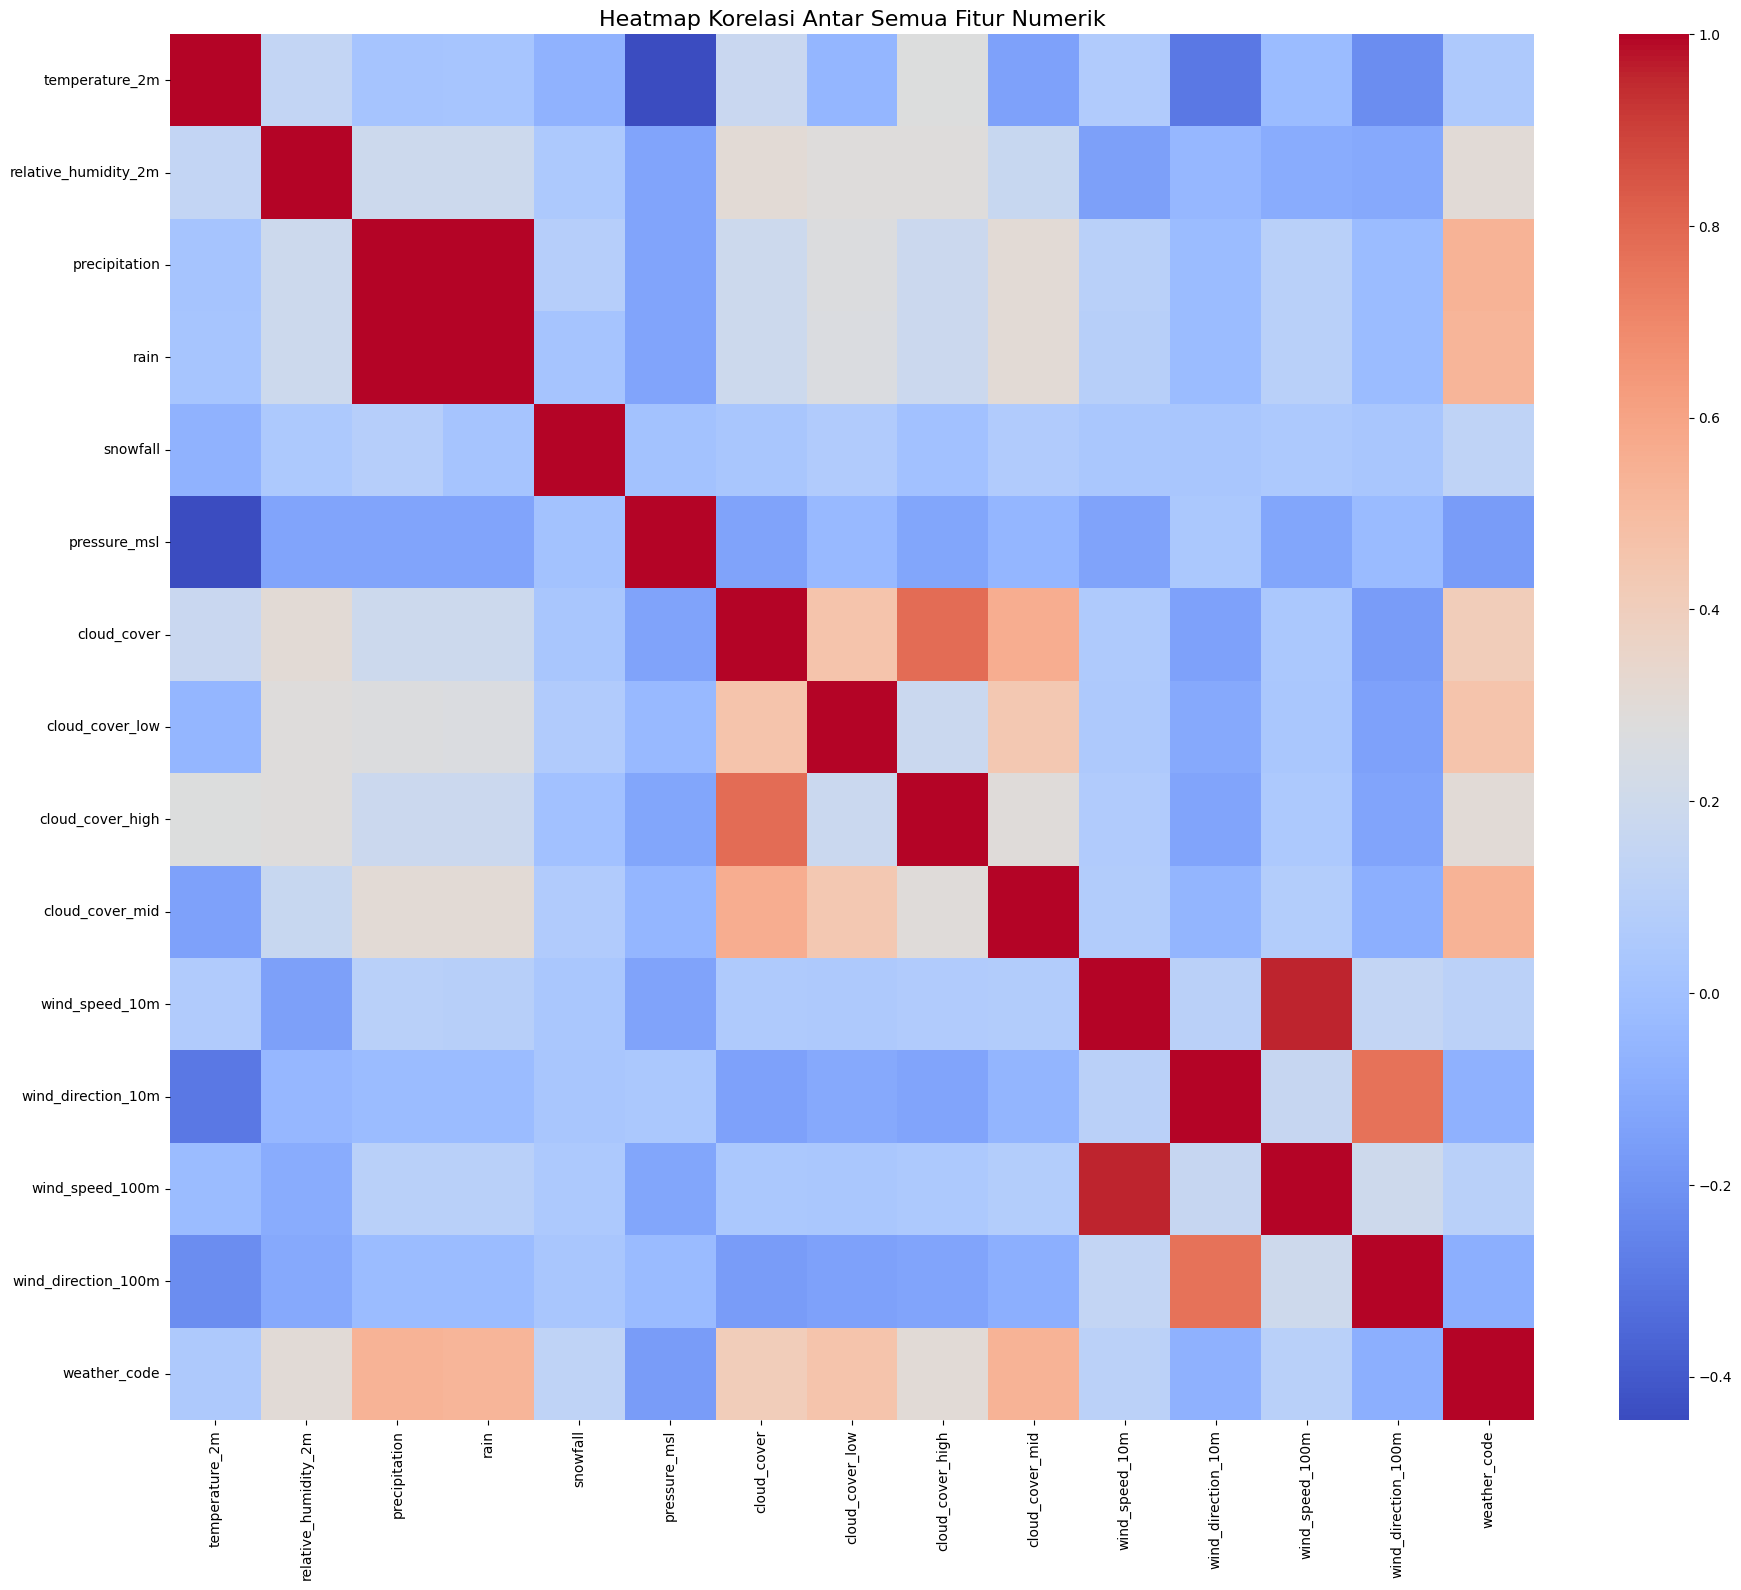

In [21]:
# Menghitung matriks korelasi untuk semua fitur
# Kita hanya akan menggunakan fitur numerik untuk korelasi
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()

# Menampilkan korelasi dari setiap fitur terhadap 'system_price'
# Diurutkan dari yang paling tinggi ke paling rendah
print(f"\nKorelasi Fitur terhadap Target ({TARGET}):")
target_correlation = correlation_matrix[TARGET].sort_values(ascending=False)
print(target_correlation)

# Visualisasi matriks korelasi dengan heatmap
# Ini membantu melihat gambaran besar hubungan antar semua variabel
plt.figure(figsize=(22, 18))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False) # annot=False agar tidak terlalu ramai
plt.title('Heatmap Korelasi Antar Semua Fitur Numerik', fontsize=16)
plt.show()

# Test JEPX API

In [21]:
!pip install selenium

   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
    --------------------------------------- 0.2/9.7 MB 3.1 MB/s eta 0:00:04
   -- ------------------------------------- 0.5/9.7 MB 5.7 MB/s eta 0:00:02
   ---- ----------------------------------- 1.2/9.7 MB 8.4 MB/s eta 0:00:02
   ------ --------------------------------- 1.5/9.7 MB 8.0 MB/s eta 0:00:02
   ------ --------------------------------- 1.6/9.7 MB 8.1 MB/s eta 0:00:01
   ------ --------------------------------- 1.6/9.7 MB 8.1 MB/s eta 0:00:01
   ------- -------------------------------- 1.7/9.7 MB 5.2 MB/s eta 0:00:02
   -------- ------------------------------- 2.0/9.7 MB 5.4 MB/s eta 0:00:02
   --------- ------------------------------ 2.2/9.7 MB 5.3 MB/s eta 0:00:02
   ---------- ----------------------------- 2.5/9.7 MB 5.2 MB/s eta 0:00:02
   ---------- ----------------------------- 2.7/9.7 MB 5.1 MB/s eta 0:00:02
   ----------- ---------------------------- 2.9/9.7 MB 5.1 MB/s eta 0:00:02
   ------------ ---

In [13]:
import pandas as pd
import requests
from io import StringIO

In [27]:
import pandas as pd
import time
from datetime import date
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait, Select
from selenium.webdriver.support import expected_conditions as EC

# --- Configuration ---
JEPX_URL = "https://www.jepx.jp/en/electricpower/market-data/intraday/" 
TABLE_CONTAINER_ID = "intraday__table"
TABLE_CLASS = "graph-section__table"

# --- Target Date ---
# Set the specific date you want to scrape: YYYY, MM, DD
# Note: Month value is 1-indexed (October = 10)
TARGET_DATE = date(2025, 10, 24)

# --- Interaction Selectors ---
SELECT_DATE_BUTTON_SELECTOR = (By.ID, "button--calender-show") 
TABLE_BUTTON_SELECTOR = (By.CSS_SELECTOR, "button[data-type='table']") 
DATEPICKER_DIV = (By.ID, "datepicker")
# New precise selector to find the TABLE element inside its container DIV
PRECISE_TABLE_SELECTOR = (By.CSS_SELECTOR, f"#{TABLE_CONTAINER_ID} table.{TABLE_CLASS}")

# --- Helper Functions ---

def setup_chrome_options() -> Options:
    """Configures Chrome options to run headless (no visible browser window)."""
    options = Options()
    # Use "new" headless mode for better performance and stability
    # options.add_argument("--headless=new") 
    # options.add_argument("--no-sandbox")
    # options.add_argument("--disable-dev-shm-usage")
    return options

def select_date_in_datepicker(driver: webdriver.Chrome, target_date: date):
    """Interacts with the jQuery UI Datepicker to select the target date."""
    
    # 1. Wait for the datepicker to be visible after clicking "Select Date"
    wait = WebDriverWait(driver, 10)
    wait.until(EC.visibility_of_element_located(DATEPICKER_DIV))
    print(f"Datepicker visible. Attempting to select date: {target_date}")

    # 2. Select the Year (by value)
    year_select_element = driver.find_element(By.CSS_SELECTOR, ".ui-datepicker-year")
    Select(year_select_element).select_by_value(str(target_date.year))
    
    # 3. Select the Month (by 0-indexed value)
    month_select_element = driver.find_element(By.CSS_SELECTOR, ".ui-datepicker-month")
    Select(month_select_element).select_by_value(str(target_date.month - 1))
    
    # Wait for the calendar to update after changing month/year
    time.sleep(1) 
    
    # 4. Select the Day
    # XPath to find the <a> element with the matching 'data-date' attribute that is not disabled
    day_xpath = f"//a[@data-date='{target_date.day}' and not(contains(@class, 'ui-datepicker-prev')) and not(contains(@class, 'ui-datepicker-next'))]"
    day_element_selector = (By.XPATH, day_xpath)

    # Wait for the specific day to be clickable
    day_element = wait.until(EC.element_to_be_clickable(day_element_selector))
    day_element.click()
    print(f"Successfully selected day {target_date.day}.")
    
    # Date selection is complete, the datepicker should now disappear
    time.sleep(1)


def scrape_jepx_table_data() -> pd.DataFrame | None:
    """
    Automates the website navigation, date selection, view switch, and table scraping.
    """
    options = setup_chrome_options()
    driver = None
    
    try:
        driver = webdriver.Chrome(options=options)
        print(f"WebDriver initialized. Navigating to: {JEPX_URL}")
        driver.get(JEPX_URL)
        wait = WebDriverWait(driver, 20)

        # Step 1: Click the 'Select Date' button to open the date picker
        print("Attempting to click 'Select Date' button...")
        select_date_button = wait.until(EC.element_to_be_clickable(SELECT_DATE_BUTTON_SELECTOR))
        select_date_button.click()

        # Step 2: Select the target date in the date picker
        select_date_in_datepicker(driver, TARGET_DATE)

        # Step 3: Click the 'Table' button to display the data
        print("Attempting to click 'Table' button to switch view...")
        table_button = wait.until(EC.element_to_be_clickable(TABLE_BUTTON_SELECTOR))
        table_button.click()

        # Step 4: Wait for the specific TABLE element to load with the new data
        print(f"Waiting for the specific data table to load (CSS Selector: {PRECISE_TABLE_SELECTOR[1]})...")
        table_element = wait.until(EC.presence_of_element_located(PRECISE_TABLE_SELECTOR))
        
        # Step 5: Extract the table data by getting the element's HTML
        table_html = table_element.get_attribute('outerHTML')
        
        # pd.read_html can parse an HTML string directly
        df_list = pd.read_html(table_html)
        
        if not df_list:
            print("Error: No table data found in the extracted HTML.")
            return None
        
        df = df_list[0]
        
        # Step 6: Clean up the DataFrame
        # Assign explicit column names based on the table header structure
        df.columns = [
            'Time_Code', 
            'Opening_Price', 
            'Highest_Price', 
            'Lowest_Price', 
            'Last_Price', 
            'Average_Price', 
            'Total_Volume_kWh', 
            'Number_of_Contracts'
        ]
        
        # Convert price/volume/contract columns to numeric, removing any non-digit characters (like commas)
        for col in df.columns[1:]:
            df[col] = df[col].astype(str).str.replace(r'[^\d.]', '', regex=True).astype(float)
        
        print(f"\nSuccessfully scraped and cleaned data for {TARGET_DATE} into Pandas DataFrame.")
        return df

    except Exception as e:
        print(f"An error occurred during the scraping process: {e}")
        print("\nEnsure ChromeDriver is installed and its path is accessible, and verify the TARGET_DATE is valid.")
        return None

    finally:
        # Ensure the browser window is closed
        if driver:
            driver.quit()

# --- Execution ---
if __name__ == '__main__':
    jepx_df = scrape_jepx_table_data()

    if jepx_df is not None:
        print("\n" + "="*50)
        print(f"  JEPX Intraday Market Data for {TARGET_DATE}")
        print("="*50)
        
        # Display the cleaned DataFrame
        print(jepx_df.head(10).to_markdown(index=False))
        
        print(f"\nTotal records retrieved: {len(jepx_df)}")
        print(f"Data types:\n{jepx_df.dtypes}")
    else:
        print("\nFailed to retrieve JEPX data.")


WebDriver initialized. Navigating to: https://www.jepx.jp/en/electricpower/market-data/intraday/
Attempting to click 'Select Date' button...
Datepicker visible. Attempting to select date: 2025-10-24
Successfully selected day 24.
Attempting to click 'Table' button to switch view...
Waiting for the specific data table to load (CSS Selector: #intraday__table table.graph-section__table)...

Successfully scraped and cleaned data for 2025-10-24 into Pandas DataFrame.


C:\Users\ideap\AppData\Local\Temp\ipykernel_22096\433578141.py:105: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df_list = pd.read_html(table_html)



  JEPX Intraday Market Data for 2025-10-24
| Time_Code   |   Opening_Price |   Highest_Price |   Lowest_Price |   Last_Price |   Average_Price |   Total_Volume_kWh |   Number_of_Contracts |
|:------------|----------------:|----------------:|---------------:|-------------:|----------------:|-------------------:|----------------------:|
| 00:00-00:30 |            8.94 |           30    |           8.37 |         8.37 |           11.44 |             102700 |                    88 |
| 00:30-01:00 |           10.6  |           16.1  |           7.92 |        10.53 |           10.01 |              56900 |                    64 |
| 01:00-01:30 |           10.6  |           16.06 |           8.1  |         8.56 |           10.26 |              22500 |                    36 |
| 01:30-02:00 |           10.71 |           16.45 |           5.71 |         8.55 |            6.91 |             183200 |                    67 |
| 02:00-02:30 |           10.64 |           16.39 |           7.61 |      